## Personal Data Analysis: Spotify Listening History

**Domain and Motivation**

This project analyzes how my personal music listening habits vary depending on external factors, specifically the weather in this case. It is personally valuable to me as music is a large part of my life, both listening to and playing, and it also happens to be one of the primary ways I express my mood. I've recently noticed in the past few years how heavily the changing of the weather and the seasons impacts my mood. I am curious to see the correlation then between the Spokane weather patterns and my listening history. 


**Data Format**

The raw data downloaded from Spotify was originally a JSON file that I then converted to a CSV for convenience. The weather data downloaded from Meteostat is a CSV file. The final format of the merged dataset is a CSV file. 

**Tables**

There are two tables included in the dataset:

1. My Spotify data collected from a Spotify streaming history export containing 2210 observations with each instance or row equating to one song play. 
    - Attributes:
        - `timestamp` - when song ended
        - `artist` - artist name
        - `track` - song name
        - `ms_played` $\to$ converted to `minutes_played` - song duration 
        - `date`, `year`, `month`, `day` - all indicators of when in time the song was played 

2. The daily weather data for the same time frame the Spotify export spans, extracted from external source Meteostat. It contains 367 observations with each row or instance equating to one day.
    - Attributes:
        - `date`
        - `avg_temp`
        - `total_precip` 
        - `avg_windspeed`

3. The merged data set joined on the attribute `date` containing 2210 observations. It lends weather context to each listening event. 

**What is being classified?**

I am predicting whether the label for `temp_category` will be "Cold", "Mild", or "Warm" based on my listening behavior.

**Temperature Categories** 

The temperature ranges were chosen to roughly reflect realistic seasonal weather patterns in Spokane. Temperatures below 6 C were categorized as "Cold," temperatures between 6°C and 18°C were categorized as "Mild," and temperatures above 18 C were categorized as "Warm." This simplified the continuous weather data into categories suitable for classification and hypothesis testing. 

**Potential Impacts**

This data analysis is a model of how one's environment influences their habits. An algorithim similar to this might be used in reccomendation systems or to create mood-based playlists. For me personally, I believe it will allow me to better understand my listening habits as well as indirectly reveal how my mood fluctuates with the weather based on what genre of music I gravitate towards with certain conditions. 

**Stakeholders**
Reccomendation based music streaming platforms, data scientists analyzing behavior, or users interested in personal analytics may all be target audiences for an algorithm such as this. 

In [40]:
import utils
import matplotlib.pyplot as plt
from scipy import stats

## Load the Data

In [41]:
df = utils.load_data("spotify_data.json")
df.head(10)

,endTime,artistName,trackName,msPlayed
0,2025-04-26 00:17,Taylor Swift,Fearless (Taylor’s Version),125919
1,2025-04-26 00:26,Taylor Swift,champagne problems,243030
2,2025-04-26 01:59,Taylor Swift,gold rush,183040
3,2025-04-26 02:03,Harry Styles,Falling,240133
4,2025-04-26 02:09,Beach House,Space Song,320466
5,2025-04-26 02:09,Yot Club,YKWIM?,39920
6,2025-04-26 02:19,Taylor Swift,All Too Well (10 Minute Version) (Taylor's Ver...,613026
7,2025-04-26 02:22,Lizzy McAlpine,ceilings,182887
8,2025-04-26 02:23,Lana Del Rey,Cinnamon Girl,1620
9,2025-04-26 02:23,Phoebe Bridgers,Savior Complex,3805


## Clean the Data

To make things cleaner, I chose to define my functions for loading, cleaning, joining, and filtering the data in a seperate utils file. Seperate cleaning functions were created for both the Spotify listening dataset and weather dataset. 

**Spotify Dataset Cleaning**

The Spotify dataset required several preprocessing steps before analysis:

- Renaming columns to more readable names:
    - `endTime` $\to$ `timestamp`
    - `artistName` $\to$ `artist`
    - `trackName` $\to$ `track`
    - `msPlayed` $\to$ `ms_played`

- Converted timestamps into datetime format using pandas. 

- Created additional date-related features:
    - `date`
    - `year`
    - `month`
    - `day`

- Standardized column names by stripping extra whitespace. 

- Converted listening duration from milliseconds to minutes:
    - `minutes_played = ms_played / 60000`

- Removed very short listening events under 30 seconds because they were unlikely to represent meaningful listening behavior.

- Removed non-music entries such as white noise tracks that could distort artist analysis.

- Removed duplicate listening entries based timestamp, artist, and track.

- Removed rows containing missing values.

**Weather Dataset Cleaning** 

The weather dataset also required preprocessing:

- Selected only the attributes relevant to the analysis:
    - `date` 
    - `tavg` 
    - `prcp` 
    - `wspd` 

- Renamed weather columns to more descriptive names:
    - `tavg` $\to$ `avg_temp`
    - `prcp` $\to$ `total_precip`
    - `wspd` $\to$ `avg_windspeed`

- Removed rows with missing dates.


**Challenges During Data Preperation**

One challenge was that the Spotify export and weather dataset had different formats. Spotify listening history was recorded per song play, while weather data was recorded daily. To merge the datasets correctly, timestamps had to be converted into matching date formats. 

Another challenge was ensuring that duplicate listening records and missing values were removed before analysis. Without cleaning the data first, the statistical analysis and classification models could have produced misleading results. 


In [42]:
df = utils.clean_data(df)
df.tail(10)

,timestamp,artist,track,ms_played,date,year,month,day,minutes_played
3429,2026-04-24 19:51:00,Blondie,Call Me,34583,2026-04-24,2026,4,24,0.576383
3430,2026-04-24 19:56:00,Michael Jackson,Billie Jean,293802,2026-04-24,2026,4,24,4.896700
3441,2026-04-24 20:00:00,Pixies,Here Comes Your Man,201187,2026-04-24,2026,4,24,3.353117
3442,2026-04-24 20:06:00,Prince,When Doves Cry,354133,2026-04-24,2026,4,24,5.902217
3444,2026-04-24 20:11:00,The Strokes,The Adults Are Talking,309053,2026-04-24,2026,4,24,5.150883
3461,2026-04-25 03:19:00,Gorillaz,On Melancholy Hill,195640,2026-04-25,2026,4,25,3.260667
3463,2026-04-25 03:23:00,Gracie Abrams,Close To You,225973,2026-04-25,2026,4,25,3.766217
3464,2026-04-25 03:26:00,Sabrina Carpenter,Nonsense,163648,2026-04-25,2026,4,25,2.727467
3466,2026-04-25 03:28:00,Tate McRae,NOBODY'S GIRL,168134,2026-04-25,2026,4,25,2.802233
3467,2026-04-25 03:32:00,Ariana Grande,we can't be friends (wait for your love),228639,2026-04-25,2026,4,25,3.810650


## Save to CSV

In [43]:
df.to_csv("spotifydata.csv", index=False)

## Join Weather Data

**Merging the Tables**

The Spotify listening dataset and weather dataset and weather dataset were merged using the shared `date` attribute. This allowed each listening event to inherit the weather conditions from the corresponding day. 

In [44]:
import pandas as pd

weather = pd.read_csv("weather_data.csv")
weather = utils.clean_weather_data(weather)

df = utils.load_data("spotifydata.csv")
df = utils.join_weather(df, weather)

df["temp_category"] = pd.cut(
    df["avg_temp"], 
    bins=[-5, 6, 18, 30],
    labels=["Cold", "Mild", "Warm"]
)

df.to_csv("spotify_weather_data.csv", index=False)
df.head()

,timestamp,artist,track,ms_played,date,year,month,day,minutes_played,avg_temp,total_precip,avg_windspeed,temp_category
0,2025-04-26 00:17:00,Taylor Swift,Fearless (Taylor’s Version),125919,2025-04-26,2025,4,26,2.098650,15.0,0.0,4.1,Mild
1,2025-04-26 00:26:00,Taylor Swift,champagne problems,243030,2025-04-26,2025,4,26,4.050500,15.0,0.0,4.1,Mild
2,2025-04-26 01:59:00,Taylor Swift,gold rush,183040,2025-04-26,2025,4,26,3.050667,15.0,0.0,4.1,Mild
3,2025-04-26 02:03:00,Harry Styles,Falling,240133,2025-04-26,2025,4,26,4.002217,15.0,0.0,4.1,Mild
4,2025-04-26 02:09:00,Beach House,Space Song,320466,2025-04-26,2025,4,26,5.341100,15.0,0.0,4.1,Mild


## Exploratory Data Analysis

**Aggregation Techniques**

Several aggregation techniques were used throughout the analysis. Artist play counts were aggregated using grouping operations to identify the most frequently listened to artists. Monthly aggregation was also used to analyze how listening behavior changed over time. Daily aggregation was performed during classification so that weather conditions could be matched with overall listeing activity for a given day. 

In [45]:
top = utils.top_artists(df)

for i, (artist, count) in enumerate(top.items(), 1):
    print(f"{i}. {artist} ({count} plays)")

1. Hozier (280 plays)
2. Noah Kahan (188 plays)
3. Taylor Swift (127 plays)
4. Sabrina Carpenter (87 plays)
5. Fleetwood Mac (67 plays)


In [46]:
# filter to only overall top artists
top_names = top.index
df_top = df[df["artist"].isin(top_names)]

# count plays by temperature category and artist
artist_weather = df_top.groupby(
    ["temp_category", "artist"],
    observed=False
).size().unstack(fill_value=0)

artist_weather

artist,Fleetwood Mac,Hozier,Noah Kahan,Sabrina Carpenter,Taylor Swift
temp_category,,,,,
Cold,9,78,64,34,5
Mild,40,185,124,25,80
Warm,18,17,0,28,42


## Summary Statistics

In [47]:
df[["minutes_played", "avg_temp"]].describe()

,minutes_played,avg_temp
count,2209.000000,2209.000000
mean,3.350660,11.196695
std,1.273450,7.638376
min,0.502500,-2.400000
25%,2.668883,5.100000
50%,3.439333,8.500000
75%,4.068667,17.700000
max,10.217100,28.800000


Summary statistics were computed for attributes such as listening duration and average temperature. These statistic helped identify the typical listening behavior, spread of temperatures, and possible outliers in the dataset. 

## Visualize the Data

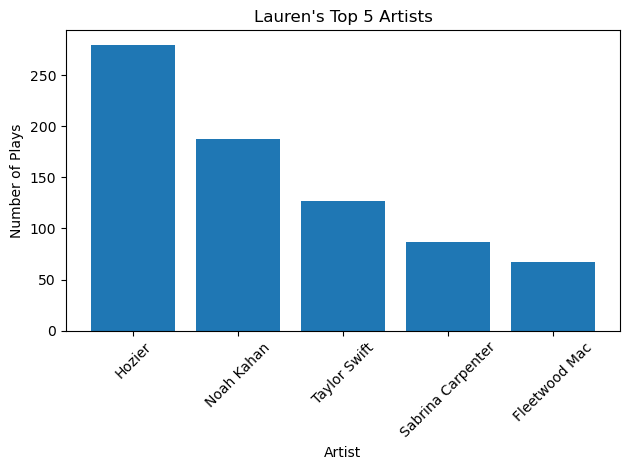

In [48]:
# top artists bar chart
plt.figure()
plt.bar(top.index, top.values)
plt.title("Lauren's Top 5 Artists")
plt.xlabel("Artist")
plt.ylabel("Number of Plays")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This visualization shows the five artists with the highest number of plays in the dataset. Hozier and Noah Kahan appeared significantly more frequently than the other artists, suggesting they dominated the listening history during the recorded time period. 

In [49]:

# filter to top artists
top_names = top.index
df_top = df[df['artist'].isin(top_names)]

In [50]:
# group by month + artist
monthly = df_top.groupby(['month', 'artist']).size().unstack(fill_value=0)

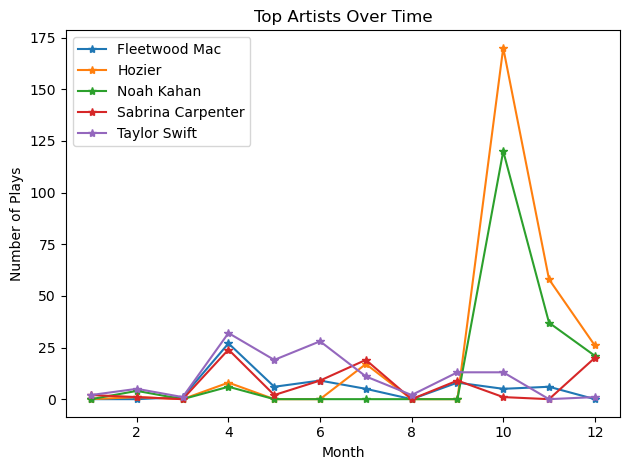

In [51]:
# plot top artists over time
plt.figure()

for artist in monthly.columns:
    plt.plot(monthly.index, monthly[artist], marker='*', label=artist)

plt.title("Top Artists Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Plays")
plt.legend()
plt.tight_layout()
plt.show()

This visualization shows how listening frequency for the top artists changed throughout the year. Certain artists showed strong increases during specific months, suggesting possible seasonal listening patterns.

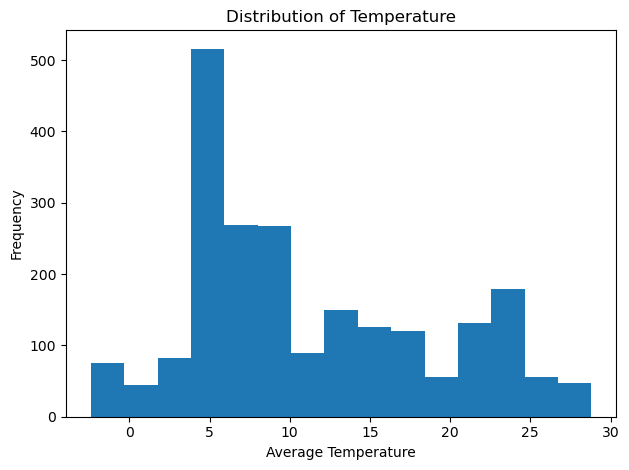

In [52]:
plt.figure()
plt.hist(df["avg_temp"], bins=15)

plt.title("Distribution of Temperature")
plt.xlabel("Average Temperature")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

This histogram displays the spread of average temperatures across the dataset. Most observations fall within mild temperature ranges, while extremely cold and extremely warm days appear less frequency.

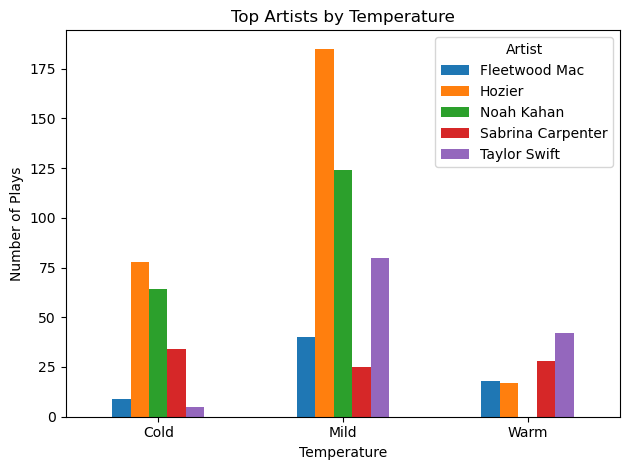

In [53]:
artist_weather.plot(kind="bar")

plt.title("Top Artists by Temperature")
plt.xlabel("Temperature")
plt.ylabel("Number of Plays")
plt.xticks(rotation=0)
plt.legend(title="Artist")
plt.tight_layout()
plt.show()

This visualization compares artist listening frequency across temperature categories. Some artists appear much more frequently during mild or cold weather conditions, suggesting a possible relationship between weather and music preference. 

## Hypothesis Test

$H_0$: Artist listening frequency is independent of temperature category.

$H_A$: Artist listening frequency varies by temperature category. 

In [54]:
# pick top artists
top_artists = df['artist'].value_counts().head(5).index
df_top = df[df["artist"].isin(top_artists)]

# build contingency table
table = pd.crosstab(df_top["temp_category"], df_top["artist"])

# run test
from scipy.stats import chi2_contingency

chi2, p_val, dof, expected = chi2_contingency(table)

print("Top Artists:", top_artists)
print("Chi-square:", chi2)
print("p-value:", p_val)


Top Artists: Index(['Hozier', 'Noah Kahan', 'Taylor Swift', 'Sabrina Carpenter',
       'Fleetwood Mac'],
      dtype='object', name='artist')
Chi-square: 156.6614565349352
p-value: 7.975882322773419e-30


The extremely small p-value suggests that the distribution of artist listening frequencies changes significantly across temperature categories. Certain artists appear much more frequently during mild or cold weather conditions than would be expected by chance alone. 

The p-value is $7.98 \times 10^-30$

Since p < 0.05, we reject the null hypothesis. There is strong evidence to suggest that listening to my top artists varies with the weather. 


## Classification Results

**Classification Task**

The goal of the classification task was to predict the temperature category ("Cold", "Mild", or "Warm") based on listening behavior features. Features included the total minutes played and number of songs played per day. 

In [55]:
# create features

daily = df.groupby("date").agg({
    "minutes_played": "sum",
    "artist": "count", 
    "avg_temp": "first",
    "temp_category": "first"
}).reset_index()

daily = daily.rename(columns={"artist": "num_plays"})

X = daily[["minutes_played", "num_plays"]]
y = daily["temp_category"]

In [56]:
daily["temp_category"].value_counts()

temp_category
Mild    62
Warm    41
Cold    38
Name: count, dtype: int64

**Distribution of Class Labels**

The dataset contains three class labels: Cold, Mild, Warm. Mild temperature appeared most frequently in the dataset, while Warm and Cold temperature occured less often. This imbalance may affect classification performance. 

In [57]:
# train/test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Hypothesis About Classification** 

I hypothesize that listening behavior would contain enough information to partially predict weather category because music preferences and listening activity may vary depending on mood, season, and environmental conditions. 

In [58]:
# kNN model

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
knn_acc = accuracy_score(y_test, y_pred_knn)

print(f"kNN Accuracy: {knn_acc:.2f}")

kNN Accuracy: 0.28


In [59]:
# decision tree

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {dt_acc:.2f}")

Decision Tree Accuracy: 0.21


**Model Performance Comparison**

The k-Nearest Neighbors classifier achieved an accuracy of approximately 28%, while the Decision Tree classifier achieved approximately 21% accuracy.

The relatively low accuracies suggest that listening behavior alone is not a strong predictor of temperature category. However, the models may still capture weak behavioral patterns associated with weather conditions. 

**Challenges with Classification**

One challenge was that listening behavior is influenced by many variables besides weather, such as mood, school schedule, time availability, and personal preference. Additionally, the dataset was relatively small for machine learning purposes, which likely limited model performance. 

## Future Improvements 

Future improvements could include using larger datasets spanning multiple years, incorporating additional weather variables such as precipitation or cloud cover, and testing more advanced machine learning models. Including audio features directly from Spotify's API could also improve prediction performance. 

## Ethical Considerations 

Although this project uses personal listening data, reccomendation system based on behavioral analysis may raise privacy concerns. Music streaming platforms collect large amounts of personal data, and users may not always understand how their information is analyzed to influence recccomendations and advertisements. 